# Unit 5: EEG 特征提取与分析

## 学习目标
- 掌握频域特征提取：功率谱密度（PSD）与频带功率
- 理解并实现脑波不对称指数（Hemispheric Asymmetry）
- 学会计算时域特征：Hjorth 参数（活动性、迁移性、复杂性）
- 构建完整的 EEG 特征向量
- 掌握特征随时间变化的动态分析方法

## 核心概念

### EEG 特征类型

EEG 特征通常分为以下几类：

| 类型 | 特征 | 说明 |
|------|------|------|
| 频域 | 频带功率 | Delta/Theta/Alpha/Beta/Gamma 各频段能量 |
| 频域 | 峰值频率 | 功率谱最大峰对应的频率 |
| 频域 | 频谱边缘频率 | 包含 95% 总能量的频率 |
| 时域 | Hjorth 参数 | 活动性、迁移性、复杂性 |
| 时域 | 统计量 | 均值、方差、偏度、峰度 |
| 时频 | 小波系数 | 多分辨率分析 |
| 空间 | 相干性 | 通道间功能连接 |

### 脑波频段与认知状态
- **Alpha (8-13 Hz)**：放松闭眼时枕叶区域显著，注意力下降时增强
- **Beta (13-30 Hz)**：认知处理、运动规划、警觉状态
- **Theta (4-8 Hz)**：冥想、记忆编码、困倦
- **Delta (0.5-4 Hz)**：深睡眠、婴儿期主导
- **Gamma (30+ Hz)**：高级认知、感觉绑定

## 1. 环境准备与数据生成

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass

print("Modules imported successfully.")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

Modules imported successfully.


| 状态        | 主要频段                    | 典型脑区分布                               | 常见解释            |
| --------- | ----------------------- | ------------------------------------ | --------------- |
| relaxed | Alpha 8–13 Hz 高         | **枕叶 O1/O2/Oz 最明显**，也可见于顶叶 Pz/P3/P4  | 闭眼放松、视觉输入减少     |
| focused | Beta 13–30 Hz 高，Alpha 低 | **额叶/中央区较明显**，如 Fz、F3/F4、Cz、C3/C4    | 注意力集中、警觉、任务参与   |
| drowsy  | Theta 4–8 Hz 高          | **额叶、中线区域明显**，如 Fz、Cz；困倦时也可扩散        | 困倦、注意力下降、浅睡过渡   |
| active  | Beta + Gamma 高          | **额叶、中央区、顶叶更常见**，如 Fz、Cz、Pz；任务相关区域增强 | 高认知负荷、复杂处理、工作记忆 |


| 脑电波   | 英文  |           常见频率范围 | 常见状态/含义             |
| ----- | --- | ---------------: | ------------------- |
| Delta | δ 波 |     **0.5–4 Hz** | 深睡、低频慢波活动           |
| Theta | θ 波 |       **4–8 Hz** | 困倦、浅睡、冥想，也可能和工作记忆有关 |
| Alpha | α 波 |      **8–13 Hz** | 闭眼放松，枕叶/顶叶常见        |
| Beta  | β 波 |     **13–30 Hz** | 注意力、警觉、思考、运动相关活动    |
| Gamma | γ 波 |     **30–45 Hz** | 高级认知、信息整合，但容易受肌电影响  |


In [3]:
# 生成模拟 EEG 数据（带不同认知状态）
def generate_state_specific_eeg(
    state: str,
    duration: float = 10.0,
    sfreq: float = 250.0,
    n_channels: int = 8
) -> np.ndarray:
    """
    生成特定认知状态下的模拟 EEG 数据
    
    不同状态模拟不同的频带功率分布：
    - 'relaxed': 高 Alpha 功率（闭眼放松）
    - 'focused': 高 Beta 功率，低 Alpha（注意力集中）
    - 'drowsy': 高 Theta 功率（困倦）
    - 'active': 高 Beta + Gamma（认知负荷高）
    
    Args:
        state: 认知状态
        duration: 持续时间（秒）
        sfreq: 采样频率
        n_channels: 通道数
    
    Returns:
        (n_channels, n_samples) EEG 数据
    """
    # 根据 state 这个字符串生成一个随机种子，让不同状态产生不同的随机数据。
    # 不同进程，数据不可复现
    np.random.seed(hash(state) % 10000)
    n_samples = int(duration * sfreq)
    t = np.arange(n_samples) / sfreq
    data = np.zeros((n_channels, n_samples))
    
    # 状态特定的权重
    state_weights = {
        'relaxed': {'delta': 5, 'theta': 8, 'alpha': 30, 'beta': 5, 'gamma': 1},
        'focused': {'delta': 3, 'theta': 5, 'alpha': 8, 'beta': 20, 'gamma': 3},
        'drowsy': {'delta': 15, 'theta': 25, 'alpha': 10, 'beta': 3, 'gamma': 0.5},
        'active': {'delta': 3, 'theta': 5, 'alpha': 5, 'beta': 25, 'gamma': 10}
    }
    
    weights = state_weights.get(state, state_weights['relaxed'])
    
    for ch in range(n_channels):
        # 通道间添加空间差异
        spatial_factor = 1.0 + 0.3 * np.sin(ch * np.pi / 4)
        phase_shift = ch * 0.2
        
        # Delta: 0.5–4 Hz
        data[ch] += weights['delta'] * spatial_factor * np.sin(2 * np.pi * 2 * t + phase_shift)
        # Theta: 4–8 Hz
        data[ch] += weights['theta'] * spatial_factor * np.sin(2 * np.pi * 6 * t + phase_shift)
        # Alpha: 8–13 Hz
        data[ch] += weights['alpha'] * spatial_factor * np.sin(2 * np.pi * 10 * t + phase_shift)
        # Beta: 13–30 Hz
        data[ch] += weights['beta'] * spatial_factor * np.sin(2 * np.pi * 20 * t + phase_shift)
        # Gamma: 30–45 Hz
        data[ch] += weights['gamma'] * spatial_factor * np.sin(2 * np.pi * 40 * t + phase_shift)
        # 噪声
        data[ch] += np.random.randn(n_samples) * 3
    
    return data


# 生成四种状态的数据
states = ['relaxed', 'focused', 'drowsy', 'active']
sfreq = 250.0
n_channels = 8
duration = 10.0

state_data = {}
for state in states:
    state_data[state] = generate_state_specific_eeg(state, duration, sfreq, n_channels)
    print(f"Generated '{state}' state data: shape {state_data[state].shape}")

Generated 'relaxed' state data: shape (8, 2500)
Generated 'focused' state data: shape (8, 2500)
Generated 'drowsy' state data: shape (8, 2500)
Generated 'active' state data: shape (8, 2500)


## 2. 频域特征提取

In [4]:
# 标准 EEG 频段定义
EEG_BANDS = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45)
}


def compute_band_power(
    psd: np.ndarray,
    freqs: np.ndarray,
    band: Tuple[float, float]
) -> float:
    """
    计算特定频段的绝对功率
    因为 PSD（功率谱密度）本身不是“某个频段的总功率”，它表示的是：
    每个频率点的功率密度（µV²/Hz）
    所以，需要积分得到频段内的总功率
    
    使用梯形积分法对 PSD 在频段内积分
    
    Args:
        psd: 功率谱密度数组 (µV²/Hz)
        freqs: 对应的频率数组
        band: (low_freq, high_freq) 元组
    
    Returns:
        float: 频段总功率 (µV²)
    """
    low, high = band
    # 找到频段范围内的频率索引
    mask = (freqs >= low) & (freqs <= high)
    # 如果超过频率范围，返回 0
    if not np.any(mask):
        return 0.0
    
    # 梯形数值积分
    band_power = np.trapezoid(psd[mask], freqs[mask])

    return float(band_power)


def extract_frequency_features(
    data: np.ndarray,
    sfreq: float,
    nperseg: int = 256
) -> Dict:
    """
    从 EEG 数据提取完整频域特征
    
    Args:
        data: (n_channels, n_samples) 数据
        sfreq: 采样频率
        nperseg: Welch 方法的段长度
    
    Returns:
        字典包含:
            - band_powers: 各通道各频段的绝对功率
            - relative_powers: 各频段相对功率（百分比）
            - total_power: 总功率
            - peak_frequencies: Alpha 频段的峰值频率
            - psd_data: 原始 PSD 数据
    """
    n_channels = data.shape[0]
    features = {
        'band_powers': {},
        'relative_powers': {},
        'total_power': {},
        'peak_frequencies': {},
        'psd_data': None
    }
    
    all_psd = []
    all_freqs = None
    
    for ch in range(n_channels):
        # 使用 Welch 方法估计 PSD
        # freqs:表示频率数组
        # psd:表示功率谱密度数组
        freqs, psd = scipy_signal.welch(
            data[ch],
            fs=sfreq,
            nperseg=min(nperseg, data.shape[1]),
            noverlap=nperseg // 2, # 50% 重叠
            window='hann',
            scaling='density'
        )
        
        if all_freqs is None:
            all_freqs = freqs
        
        # 计算各频段功率
        ch_band_powers = {}
        total = 0
        for band_name, band_range in EEG_BANDS.items():
            power = compute_band_power(psd, freqs, band_range)
            ch_band_powers[band_name] = power
            total += power
        
        # 计算相对功率
        ch_relative = {k: v / total if total > 0 else 0 for k, v in ch_band_powers.items()}
        
        # 找出Alpha 频段中，PSD 最大的位置在多少Hz处
        alpha_mask = (freqs >= 8) & (freqs <= 13)
        if np.any(alpha_mask):
            peak_freq = freqs[alpha_mask][np.argmax(psd[alpha_mask])]
        else:
            peak_freq = 0
        
        features['band_powers'][f'CH{ch+1}'] = ch_band_powers
        features['relative_powers'][f'CH{ch+1}'] = ch_relative
        features['total_power'][f'CH{ch+1}'] = total
        features['peak_frequencies'][f'CH{ch+1}'] = peak_freq
        
        all_psd.append(psd)
    
    features['psd_data'] = {'freqs': all_freqs, 'psd': np.array(all_psd)} 
    # np.array(all_psd) (n_channels, n_freq)
    return features


# 提取 'relaxed' 状态的特征
relaxed_features = extract_frequency_features(state_data['relaxed'], sfreq)
print("Feature extraction complete.")
print(f"Peak frequencies (Alpha range):")
for ch, pf in relaxed_features['peak_frequencies'].items():
    print(f"  {ch}: {pf:.1f} Hz")

Feature extraction complete.
Peak frequencies (Alpha range):
  CH1: 9.8 Hz
  CH2: 9.8 Hz
  CH3: 9.8 Hz
  CH4: 9.8 Hz
  CH5: 9.8 Hz
  CH6: 9.8 Hz
  CH7: 9.8 Hz
  CH8: 9.8 Hz


## 3. 对比不同状态的频域特征

In [5]:
# 提取所有状态的特征
all_features = {}
for state in states:
    all_features[state] = extract_frequency_features(state_data[state], sfreq)
    print(f"Extracted features for '{state}' state.")

# 创建频带功率对比表
print("\n" + "=" * 80)
print("Alpha Band Power Comparison (Channel 1)")
print("=" * 80)

for state in states:
    alpha_power = all_features[state]['band_powers']['CH1']['alpha']
    beta_power = all_features[state]['band_powers']['CH1']['beta']
    alpha_rel = all_features[state]['relative_powers']['CH1']['alpha']
    print(f"  {state:10s}: Alpha={alpha_power:8.1f}µV²  |  "
          f"Beta={beta_power:8.1f}µV²  |  "
          f"Alpha%={alpha_rel*100:5.1f}%")

Extracted features for 'relaxed' state.
Extracted features for 'focused' state.
Extracted features for 'drowsy' state.
Extracted features for 'active' state.

Alpha Band Power Comparison (Channel 1)
  relaxed   : Alpha=   433.0µV²  |  Beta=    13.6µV²  |  Alpha%= 88.0%
  focused   : Alpha=    30.2µV²  |  Beta=   201.9µV²  |  Alpha%= 11.9%
  drowsy    : Alpha=    47.8µV²  |  Beta=     5.8µV²  |  Alpha%= 10.5%
  active    : Alpha=    12.9µV²  |  Beta=   311.2µV²  |  Alpha%=  3.3%


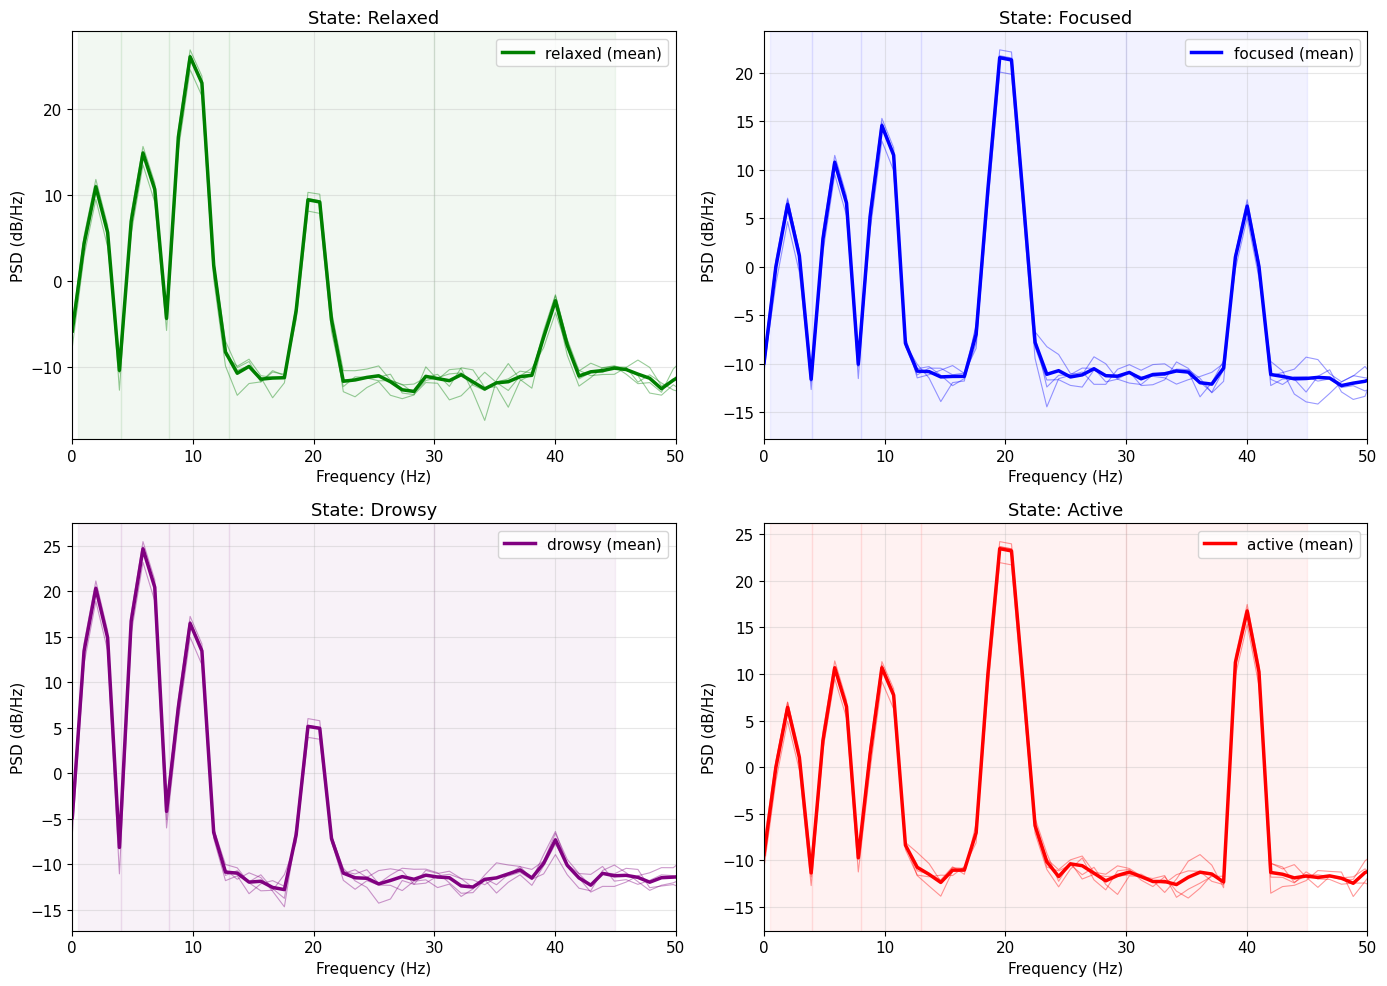

In [6]:
# 可视化：多状态 PSD 对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'relaxed': 'green', 'focused': 'blue', 'drowsy': 'purple', 'active': 'red'}

for idx, state in enumerate(states):
    ax = axes[idx]
    psd_data = all_features[state]['psd_data']
    freqs = psd_data['freqs']
    
    # 显示前 4 个通道的平均 PSD
    for ch in range(4):
        ax.plot(freqs, 10 * np.log10(psd_data['psd'][ch] + 1e-15),
               color=colors[state], alpha=0.4, linewidth=0.8)
    
    # 平均 PSD
    mean_psd = np.mean(psd_data['psd'][:4], axis=0)
    ax.plot(freqs, 10 * np.log10(mean_psd + 1e-15),
           color=colors[state], linewidth=2.5, label=f'{state} (mean)')
    
    ax.set_title(f'State: {state.capitalize()}', fontsize=13)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (dB/Hz)')
    ax.set_xlim(0, 50)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 标注频段
    for band_name, (lo, hi) in EEG_BANDS.items():
        ax.axvspan(lo, hi, alpha=0.05, color=colors[state])

plt.tight_layout()
plt.show()

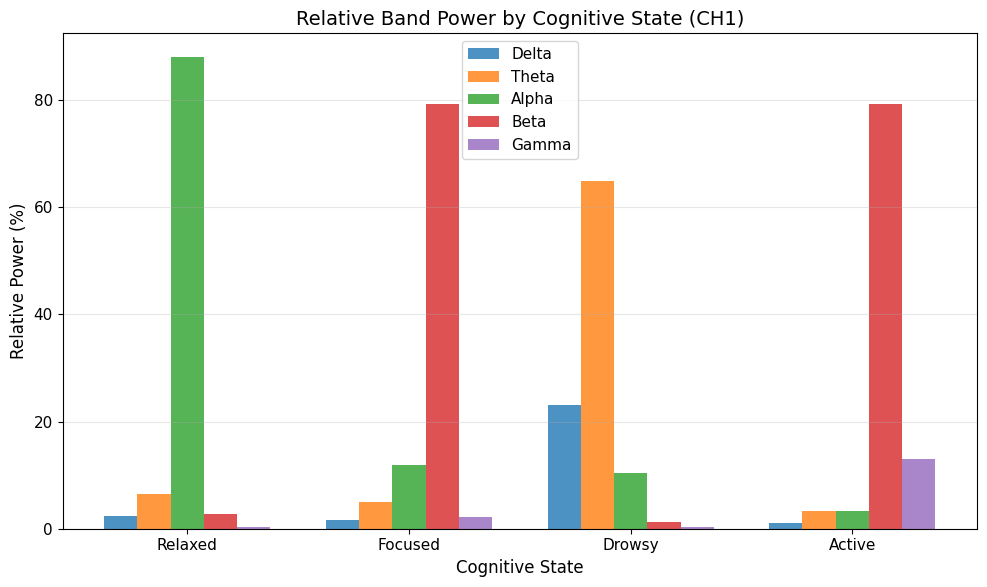

频带功率分组柱状图绘制完成


In [7]:
# 频带功率分组柱状图
fig, ax = plt.subplots(figsize=(10, 6))

band_names = list(EEG_BANDS.keys())
x = np.arange(len(states))
width = 0.15

# 用i来错开band的柱状图，避免重叠
for i, band in enumerate(band_names):
    powers = []
    for state in states:
        # 取 CH1 的相对功率
        powers.append(all_features[state]['relative_powers']['CH1'][band] * 100)
    # ax.bar() 默认是“柱子的中心点”对应你传入的 x 坐标
    ax.bar(x + i * width, powers, width, label=band.capitalize(), alpha=0.8) # 大写首字母

ax.set_xlabel('Cognitive State', fontsize=12)
ax.set_ylabel('Relative Power (%)', fontsize=12)
ax.set_title('Relative Band Power by Cognitive State (CH1)', fontsize=14)
ax.set_xticks(x + width * 2) # 设置刻度刻在哪里
ax.set_xticklabels([s.capitalize() for s in states]) # 给每个刻度添加标签
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("频带功率分组柱状图绘制完成")

## 4. 时域特征提取（Hjorth 参数）

In [8]:
def compute_hjorth_parameters(data: np.ndarray) -> Dict[str, float]:
    """
    计算 Hjorth 参数：活动性（Activity）、迁移性（Mobility）、复杂性（Complexity）
    
    Hjorth 参数描述了信号的时域统计特性：
    - Activity: 信号的方差，反映信号的整体能量
    - Mobility: 信号一阶导数的标准差 / 信号标准差，反映平均频率
    - Complexity: 二阶导数的 mobility / 一阶导数的 mobility，反映频率变化
    
    Args:
        data: 1D 信号数组
    
    Returns:
        字典包含 activity, mobility, complexity
    """
    # Activity = 方差variance
    activity = np.var(data)
    
    # 计算一阶导数（相邻差分）
    deriv1 = np.diff(data)
    
    # Mobility = std(deriv1) / std(signal)
    mobility = np.std(deriv1) / np.std(data) if np.std(data) > 0 else 0
    
    # 计算二阶导数
    deriv2 = np.diff(deriv1)
    
    # Complexity = mobility(deriv2) / mobility(deriv1)
    mobility_deriv1 = np.std(deriv2) / np.std(deriv1) if np.std(deriv1) > 0 else 0
    complexity = mobility_deriv1 / mobility if mobility > 0 else 0
    
    return {
        'activity': float(activity),
        'mobility': float(mobility),
        'complexity': float(complexity)
    }


def compute_time_domain_features(data: np.ndarray) -> Dict[str, float]:
    """
    计算完整的时域特征集
    
    Args:
        data: 1D 信号
    
    Returns:
        字典包含多种时域特征
    """
    hjorth = compute_hjorth_parameters(data)
    
    return {
        'mean': float(np.mean(data)),  # 均值：信号的平均值
        'std': float(np.std(data)),  # 标准差：信号的离散程度
        'variance': float(np.var(data)),  # 方差：信号波动的平方度量
        'skewness': float(skew(data)),  # 偏度：信号分布的不对称性
        'kurtosis': float(kurtosis(data)),  # 峰度：信号分布的尖锐程度
        'peak_to_peak': float(np.ptp(data)),  # 峰峰值：最大值与最小值之差
        'rms': float(np.sqrt(np.mean(data**2))),  # 均方根：信号的有效值
        'hjorth_activity': hjorth['activity'],  # Hjorth活动性：信号方差
        'hjorth_mobility': hjorth['mobility'],  # Hjorth迁移性：平均频率度量
        'hjorth_complexity': hjorth['complexity']  # Hjorth复杂性：频率变化度量
    }


# 计算各状态的时域特征
print("=" * 90)
print("Time-Domain Feature Comparison (Channel 1)")
print("=" * 90)
print(f"{'State':<12} | {'Mean':>8} | {'Std':>8} | {'Skew':>8} | "
      f"{'Kurt':>8} | {'P2P':>8} | {'Activity':>10} | {'Mobility':>8} | {'Complexity':>10}")
print("-" * 90)

for state in states:
    td_features = compute_time_domain_features(state_data[state][0])
    print(f"{state:<12} | {td_features['mean']:>8.2f} | {td_features['std']:>8.2f} | "
          f"{td_features['skewness']:>8.3f} | {td_features['kurtosis']:>8.3f} | "
          f"{td_features['peak_to_peak']:>8.2f} | {td_features['hjorth_activity']:>10.2f} | "
          f"{td_features['hjorth_mobility']:>8.3f} | {td_features['hjorth_complexity']:>10.4f}")

Time-Domain Feature Comparison (Channel 1)
State        |     Mean |      Std |     Skew |     Kurt |      P2P |   Activity | Mobility | Complexity
------------------------------------------------------------------------------------------
relaxed      |     0.01 |    22.77 |   -0.006 |   -1.146 |    93.26 |     518.40 |    0.313 |     3.3801
focused      |    -0.02 |    16.20 |   -0.009 |   -0.971 |    79.64 |     262.30 |    0.530 |     1.8364
drowsy       |    -0.09 |    22.12 |    0.015 |   -0.652 |    96.63 |     489.14 |    0.245 |     5.5250
active       |     0.03 |    20.03 |   -0.006 |   -1.005 |    88.39 |     401.38 |    0.597 |     1.5220


| State   | Mean  | Std   | Skew   | Kurt   | P2P   | Activity | Mobility | Complexity |
|---------|------:|------:|-------:|-------:|------:|---------:|---------:|-----------:|
| relaxed | -0.09 | 22.74 |  0.004 | -1.146 | 91.54 |   517.02 |    0.314 |     3.4026 |
| focused | -0.01 | 16.14 |  0.006 | -0.989 | 75.26 |   260.56 |    0.532 |     1.8317 |
| drowsy  |  0.07 | 22.10 | -0.022 | -0.651 | 92.60 |   488.30 |    0.248 |     5.5117 |
| active  |  0.10 | 20.03 | -0.013 | -0.992 | 91.74 |   401.05 |    0.597 |     1.5129 |

*Table 1. Time-Domain Feature Comparison (Channel 1).*

## 5. 空间特征：脑区不对称指数

In [9]:
def compute_asymmetry_index(
    left_power: float,
    right_power: float
) -> float:
    """
    计算半球不对称指数
    
    公式: AI = (L - R) / (L + R)
    - AI > 0: 左半球功率更高
    - AI < 0: 右半球功率更高
    - AI = 0: 对称
    
    Args:
        left_power: 左半球频带功率
        right_power: 右半球频带功率
    
    Returns:
        float: 不对称指数 (-1 到 +1)
    """
    total = left_power + right_power
    if total == 0:
        return 0.0
    return (left_power - right_power) / total


# 使用标准 10-20 系统通道配对
# 对于 8 通道：Fp1/Fp2, F3/F4, C3/C4, P3/P4
hemisphere_pairs = [
    ('Fp1', 'Fp2', 0, 1),
    ('F3', 'F4', 2, 3),
    ('C3', 'C4', 4, 5),
    ('P3', 'P4', 6, 7)
]

channel_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4']

print("=" * 70)
print("Alpha Asymmetry Index by State")
print("=" * 70)

for state in states:
    print(f"\n{state.upper()}:")
    for left_name, right_name, left_idx, right_idx in hemisphere_pairs:
        left_alpha = all_features[state]['band_powers'][f'CH{left_idx+1}']['alpha']
        right_alpha = all_features[state]['band_powers'][f'CH{right_idx+1}']['alpha']
        ai = compute_asymmetry_index(left_alpha, right_alpha)
        print(f"  {left_name} vs {right_name}: AI = {ai:+.4f} "
              f"({'Left' if ai > 0 else 'Right'} dominant)")

Alpha Asymmetry Index by State

RELAXED:
  Fp1 vs Fp2: AI = -0.1902 (Right dominant)
  F3 vs F4: AI = +0.0690 (Left dominant)
  C3 vs C4: AI = +0.2424 (Left dominant)
  P3 vs P4: AI = -0.1234 (Right dominant)

FOCUSED:
  Fp1 vs Fp2: AI = -0.1998 (Right dominant)
  F3 vs F4: AI = +0.0529 (Left dominant)
  C3 vs C4: AI = +0.2635 (Left dominant)
  P3 vs P4: AI = -0.1057 (Right dominant)

DROWSY:
  Fp1 vs Fp2: AI = -0.1948 (Right dominant)
  F3 vs F4: AI = +0.0640 (Left dominant)
  C3 vs C4: AI = +0.2189 (Left dominant)
  P3 vs P4: AI = -0.1247 (Right dominant)

ACTIVE:
  Fp1 vs Fp2: AI = -0.1944 (Right dominant)
  F3 vs F4: AI = +0.0491 (Left dominant)
  C3 vs C4: AI = +0.2102 (Left dominant)
  P3 vs P4: AI = -0.1302 (Right dominant)


## 6. 滑动窗口特征提取（动态分析）

In [ ]:
def extract_sliding_window_features(
    data: np.ndarray,
    sfreq: float,
    window_size: float = 2.0,
    step_size: float = 0.5
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    在滑动窗口上提取时变特征
    
    Args:
        data: (n_channels, n_samples) 数据
        sfreq: 采样频率
        window_size: 窗口长度（秒）
        step_size: 步长（秒）
    
    Returns:
        timestamps: 窗口中心时间戳
        features: 字典，键为特征名，值为 (n_windows,) 数组
    """
    n_channels, n_samples = data.shape # 数据通道数和样本数
    window_samples = int(window_size * sfreq)  # 窗口样本数
    step_samples = int(step_size * sfreq)  # 步长样本数
    
    n_windows = (n_samples - window_samples) // step_samples + 1 # 窗口数量
    timestamps = np.zeros(n_windows) # 窗口中心时间戳
    
    # 初始化特征存储
    band_features = {band: np.zeros((n_windows, n_channels)) for band in EEG_BANDS}
    
    for w in range(n_windows):
        start = w * step_samples      # [0, 125, 250, 375, 500]
        end = start + window_samples  # [500, 625, 750, 875, 1000]
        mid = (start + end) / 2       # [250, 375, 500, 625, 750]
        timestamps[w] = mid / sfreq   # 每个窗口中心时间戳
        
        # 提取当前窗口数据
        window_data = data[:, start:end]
        
        for ch in range(n_channels):
            freqs, psd = scipy_signal.welch(
                window_data[ch], fs=sfreq,
                nperseg=min(256, window_samples),
                noverlap=128
            )
            
            for band_name, (lo, hi) in EEG_BANDS.items():
                band_features[band_name][w, ch] = compute_band_power(psd, freqs, (lo, hi))
    
    return timestamps, band_features


# 创建状态切换数据：前 5 秒 relaxed，后 5 秒 focused
transition_data = np.hstack([
    state_data['relaxed'][:, :int(5 * sfreq)],
    state_data['focused'][:, :int(5 * sfreq)]
])
print(f"Transition data shape: {transition_data.shape}")

# 提取滑动窗口特征
ts, dyn_features = extract_sliding_window_features(
    transition_data, sfreq,
    window_size=2.0, step_size=0.25
)
print(f"Number of windows: {len(ts)}")

Transition data shape: (8, 2500)
Number of windows: 33


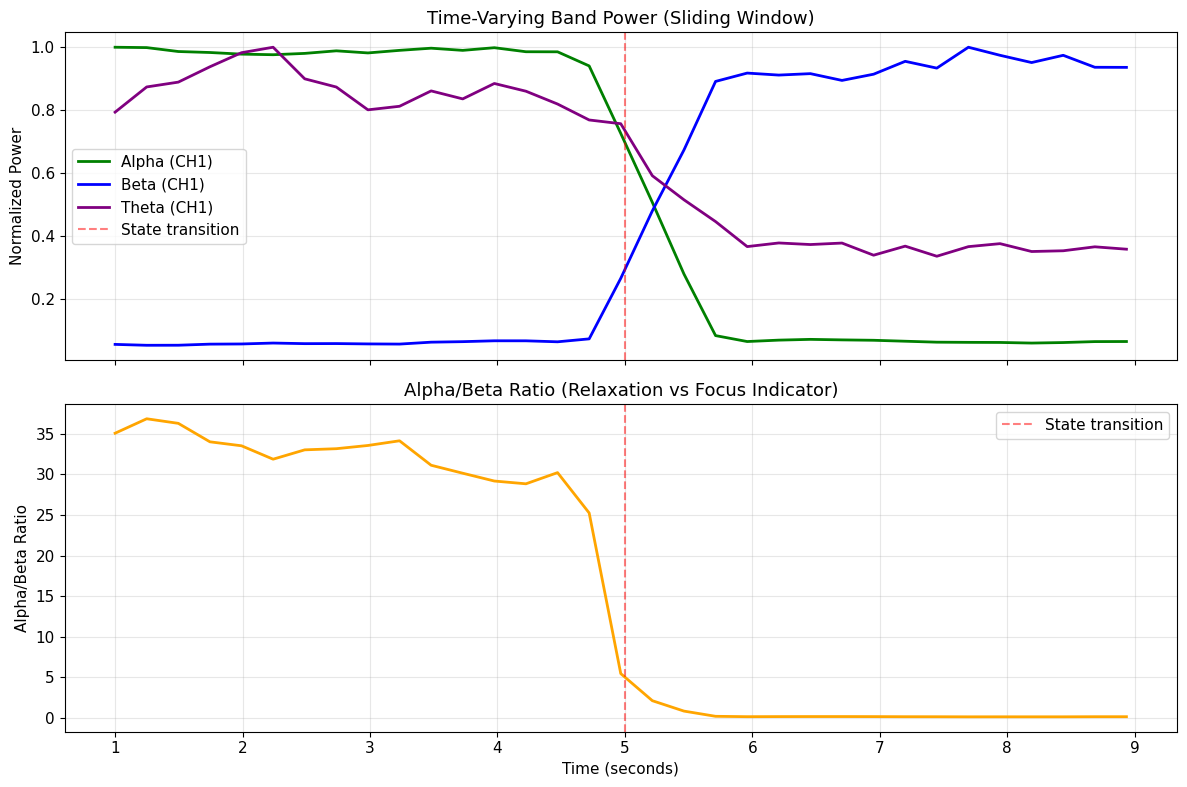

In [11]:
# 可视化动态特征变化
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 归一化
alpha_norm = dyn_features['alpha'][:, 0] / np.max(dyn_features['alpha'][:, 0])
beta_norm = dyn_features['beta'][:, 0] / np.max(dyn_features['beta'][:, 0])
theta_norm = dyn_features['theta'][:, 0] / np.max(dyn_features['theta'][:, 0])

axes[0].plot(ts, alpha_norm, 'g-', linewidth=2, label='Alpha (CH1)')
axes[0].plot(ts, beta_norm, 'b-', linewidth=2, label='Beta (CH1)')
axes[0].plot(ts, theta_norm, 'purple', linewidth=2, label='Theta (CH1)')
axes[0].axvline(x=5.0, color='red', linestyle='--', alpha=0.5, label='State transition')
axes[0].set_ylabel('Normalized Power', fontsize=11)
axes[0].set_title('Time-Varying Band Power (Sliding Window)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Alpha/Beta 比值（常用于注意力/放松指标）
alpha_beta_ratio = dyn_features['alpha'][:, 0] / (dyn_features['beta'][:, 0] + 1e-10)
axes[1].plot(ts, alpha_beta_ratio, 'orange', linewidth=2)
axes[1].axvline(x=5.0, color='red', linestyle='--', alpha=0.5, label='State transition')
axes[1].set_xlabel('Time (seconds)', fontsize=11)
axes[1].set_ylabel('Alpha/Beta Ratio', fontsize=11)
axes[1].set_title('Alpha/Beta Ratio (Relaxation vs Focus Indicator)', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 构建完整特征向量

In [17]:
def build_feature_vector(
    data: np.ndarray,
    sfreq: float,
    channel_labels: Optional[List[str]] = None
) -> Tuple[np.ndarray, List[str]]:
    """
    构建用于机器学习的完整 EEG 特征向量
    
    包含特征:
    - 各通道各频段绝对功率 (5 bands * 8 channels = 40)
    - 各通道各频段相对功率 (5 bands * 8 channels = 40)
    - 各通道 Hjorth 参数 (3 * 8 = 24)
    - 各通道统计量 (std, skewness, kurtosis = 3 * 8 = 24)
    - 半球不对称指数 (5 bands * 4 pairs = 20)
    总计: 148 维特征
    
    Args:
        data: (n_channels, n_samples)
        sfreq: 采样频率
        channel_labels: 通道名称
    
    Returns:
        feature_vector: 1D 特征数组
        feature_names: 特征名称列表
    """
    n_channels = data.shape[0]
    if channel_labels is None:
        channel_labels = [f'CH{i+1}' for i in range(n_channels)]
    
    features = []
    names = []
    
    # 1. 频域特征
    freq_features = extract_frequency_features(data, sfreq)
    for ch_name in channel_labels:
        for band_name in EEG_BANDS:
            features.append(freq_features['band_powers'][ch_name][band_name])
            names.append(f'{ch_name}_{band_name}_abs_power')
    
    for ch_name in channel_labels:
        for band_name in EEG_BANDS:
            features.append(freq_features['relative_powers'][ch_name][band_name])
            names.append(f'{ch_name}_{band_name}_rel_power')
    
    # 2. 时域特征
    for ch_idx in range(n_channels):
        td = compute_time_domain_features(data[ch_idx])
        for key in ['std', 'skewness', 'kurtosis']:
            features.append(td[key])
            names.append(f'{channel_labels[ch_idx]}_{key}')
    
    # 3. Hjorth 参数
    for ch_idx in range(n_channels):
        hj = compute_hjorth_parameters(data[ch_idx])
        for key in ['activity', 'mobility', 'complexity']:
            features.append(hj[key])
            names.append(f'{channel_labels[ch_idx]}_{key}')
    
    # 4. 不对称指数
    hemisphere_pairs = [(0, 1), (2, 3), (4, 5), (6, 7)]
    pair_labels = ['Fp', 'F', 'C', 'P']
    
    for band_name in EEG_BANDS:
        for pair_idx, (left, right) in enumerate(hemisphere_pairs):
            if left < n_channels and right < n_channels:
                left_power = freq_features['band_powers'][f'CH{left+1}'][band_name]
                right_power = freq_features['band_powers'][f'CH{right+1}'][band_name]
                ai = compute_asymmetry_index(left_power, right_power)
                features.append(ai)
                names.append(f'{pair_labels[pair_idx]}_{band_name}_asymmetry')
    
    return np.array(features), names


# 为每个状态构建特征向量
feature_vectors = {}
feature_names = None
channel_names = ['CH1', 'CH2', 'CH3', 'CH4', 'CH5', 'CH6', 'CH7', 'CH8']
# channel_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4']
for state in states:
    vec, names = build_feature_vector(state_data[state], sfreq, channel_names)
    feature_vectors[state] = vec
    if feature_names is None:
        feature_names = names

print(f"Feature vector dimension: {len(feature_names)}")
print(f"\nFirst 20 feature names:")
for i, name in enumerate(feature_names[:20]):
    print(f"  [{i:2d}] {name}")
print(f"  ... ({len(feature_names)} total)")

Feature vector dimension: 148

First 20 feature names:
  [ 0] CH1_delta_abs_power
  [ 1] CH1_theta_abs_power
  [ 2] CH1_alpha_abs_power
  [ 3] CH1_beta_abs_power
  [ 4] CH1_gamma_abs_power
  [ 5] CH2_delta_abs_power
  [ 6] CH2_theta_abs_power
  [ 7] CH2_alpha_abs_power
  [ 8] CH2_beta_abs_power
  [ 9] CH2_gamma_abs_power
  [10] CH3_delta_abs_power
  [11] CH3_theta_abs_power
  [12] CH3_alpha_abs_power
  [13] CH3_beta_abs_power
  [14] CH3_gamma_abs_power
  [15] CH4_delta_abs_power
  [16] CH4_theta_abs_power
  [17] CH4_alpha_abs_power
  [18] CH4_beta_abs_power
  [19] CH4_gamma_abs_power
  ... (148 total)


(4, 148)
(4, 148)


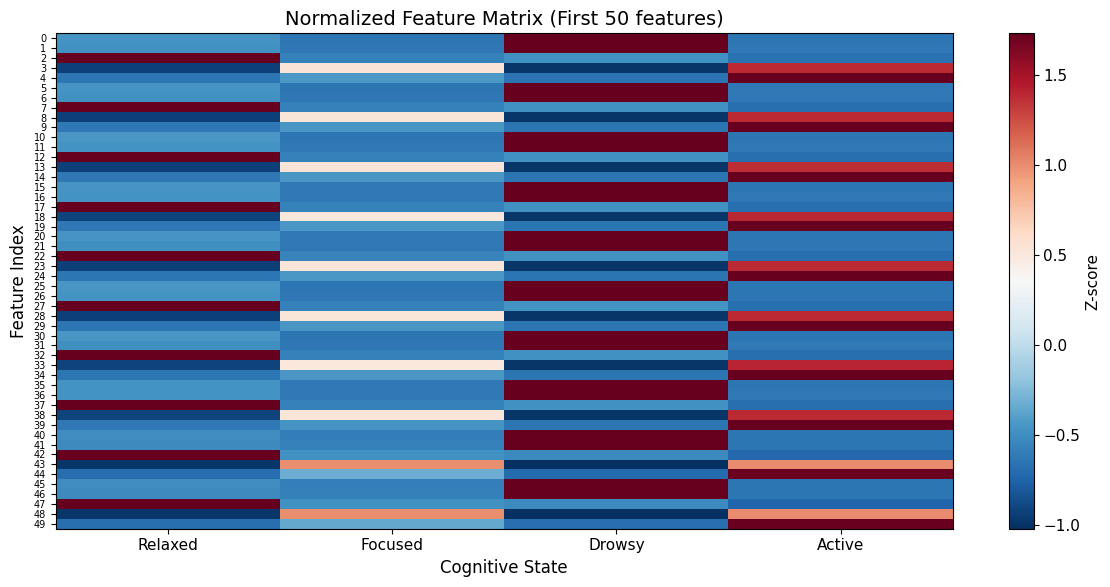

In [ ]:
# 特征矩阵可视化
feature_matrix = np.array([feature_vectors[s] for s in states])
print(feature_matrix.shape)

# 归一化（z-score）
mean = np.mean(feature_matrix, axis=0)
std = np.std(feature_matrix, axis=0)
std[std == 0] = 1  # 防止除零
normalized = (feature_matrix - mean) / std
print(normalized.shape)

# 显示部分特征的热图
fig, ax = plt.subplots(figsize=(12, 6))

# 矩阵行作为y轴，列作为x轴
im = ax.imshow(
    normalized[:, :50].T,  # 转置后的归一化特征矩阵，仅显示前50个特征
    aspect='auto',         # 自动调整纵横比
    cmap='RdBu_r',         # 红蓝反转色图，用于显示正负值
    extent=[0, len(states), 50, 0]  # 设置坐标范围[xmin, xmax, ymin, ymax]
)

ax.set_yticks(np.arange(0.5, 50.5, 1))
ax.set_yticklabels([f"{i}" for i in range(50)], fontsize=7)
ax.set_xticks(np.arange(0.5, len(states) + 0.5, 1))
ax.set_xticklabels([s.capitalize() for s in states])
ax.set_xlabel('Cognitive State', fontsize=12)
ax.set_ylabel('Feature Index', fontsize=12)
ax.set_title('Normalized Feature Matrix (First 50 features)', fontsize=14)
plt.colorbar(im, ax=ax, label='Z-score')

plt.tight_layout()
plt.show()

## 8. 知识点总结

### 关键特征及其含义
1. **频带功率**：最基本且最有区分力的特征
2. **相对功率**：消除个体差异，提高跨被试泛化
3. **Alpha/Beta 比值**：常用于放松 vs 注意力分类
4. **Hjorth 复杂性**：信号频率组成的变化率
5. **不对称指数**：与情绪状态相关（左侧 vs 右侧激活）

### 特征工程最佳实践
- 使用 **Welch 方法** 而非简单 FFT，降低方差
- **窗口大小**影响特征稳定性：越长越稳定但时间分辨率越低
- **重叠窗口**（如 50%）增加样本量
- 特征**标准化**（z-score）对机器学习很重要

## 9. 练习任务

1. 实现频带功率比特征（Theta/Alpha, Alpha/Beta, Beta/Gamma）
2. 添加频谱边缘频率（SEF95）特征：包含 95% 功率的频率点
3. 计算通道间相干性（coherence）作为功能连接特征
4. 使用 sklearn 的 SVM 或随机森林对四种状态进行分类

---
*参考资料: [SciPy Signal](https://docs.scipy.org/doc/scipy/reference/signal.html)*